# 1000 Genomes Analysis

## Line plot of base-pair location (midpoint) vs per-tree distance, by population.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

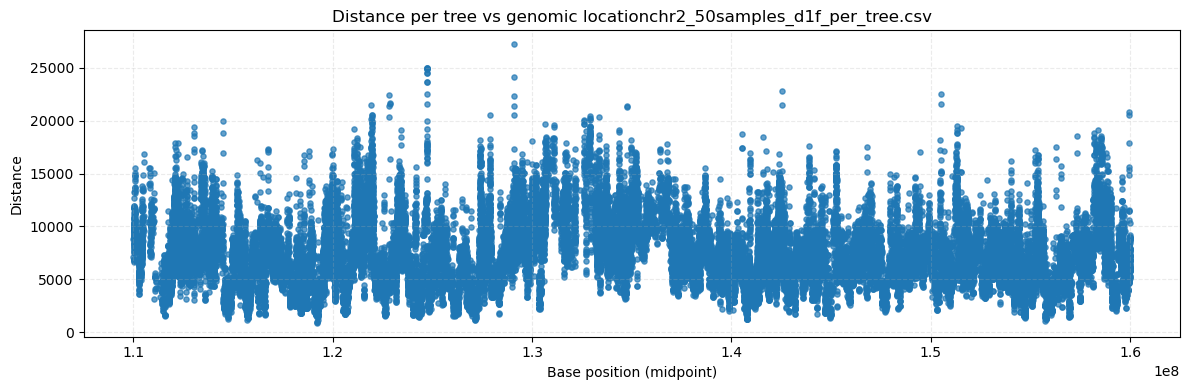

In [2]:
base = Path('.')
candidates = [ 
    base / 'chr2_50samples_dif_per_tree.csv',
    base / 'chr2_50samples_d1f_per_tree.csv',
    base / 'dif_per_tree.csv',
    base / 'd1f_per_tree.csv',
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('No distance CSV found. Expected one of: ' + ', '.join(str(p.name) for p in candidates))

df = pd.read_csv(csv_path)

if 'mid' not in df.columns:
    raise KeyError("Column 'mid' not found in distance CSV.")

dist_col = None
for c in ['distance', 'd1f_distance', 'dif_distance']:
    if c in df.columns:
        dist_col = c
        break
if dist_col is None:
    raise KeyError("No distance column found. Tried: distance, d1f_distance, dif_distance")

plt.figure(figsize=(12, 4))
plt.scatter(df['mid'], df[dist_col], s=14, alpha=0.7)
plt.xlabel('Base position (midpoint)')
plt.ylabel('Distance')
plt.title(f'Distance per tree vs genomic location{csv_path.name}')
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

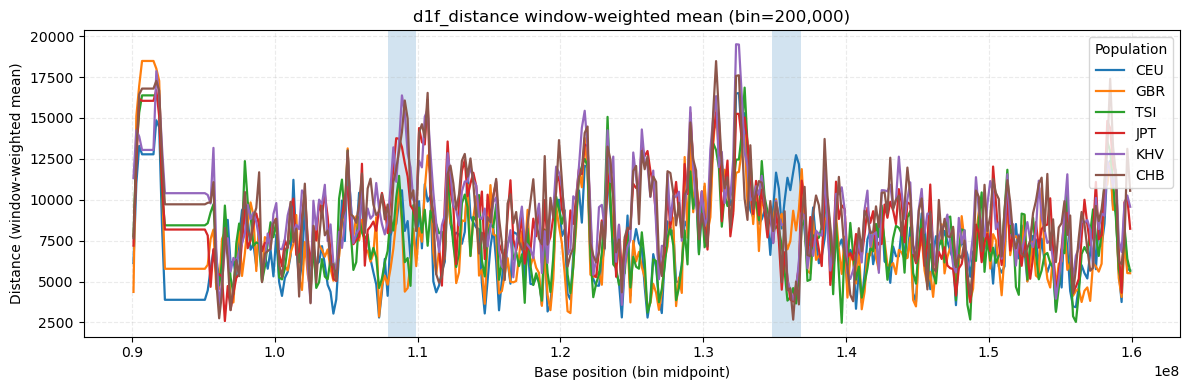

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load CSVs (per population)
# -----------------------
base = Path(".")
results_dir = base / "results"

# NOTE: 1000 Genomes population is CEU (not CER)
target_pops = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]

csv_paths = {pop: results_dir / f"chr2_50samples_{pop}_d1f_per_tree.csv" for pop in target_pops}

missing = [pop for pop, p in csv_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing distance CSV(s): "
        + ", ".join(f"{pop} ({csv_paths[pop].name})" for pop in missing)
    )

# Read CSVs
dfs = {pop: pd.read_csv(path) for pop, path in csv_paths.items()}

# Detect distance column (assume consistent across files)
dist_candidates = ["distance", "d1f_distance", "dif_distance"]
dist_col = next((c for c in dist_candidates if c in next(iter(dfs.values())).columns), None)
if dist_col is None:
    raise KeyError("No distance column found. Tried: " + ", ".join(dist_candidates))

# Validate + coerce types
required_cols = ["left", "right", dist_col]
for pop, df in dfs.items():
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{pop}: missing columns {missing_cols} in {csv_paths[pop].name}")

    df = df.copy()
    for c in required_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=required_cols)
    df = df[df["right"] > df["left"]]
    df = df.sort_values("left")

    dfs[pop] = df

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

x0 = min(df["left"].min() for df in dfs.values())
x1 = max(df["right"].max() for df in dfs.values())

# snap to bin edges
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines)
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

for pop, df in dfs.items():
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,})")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()


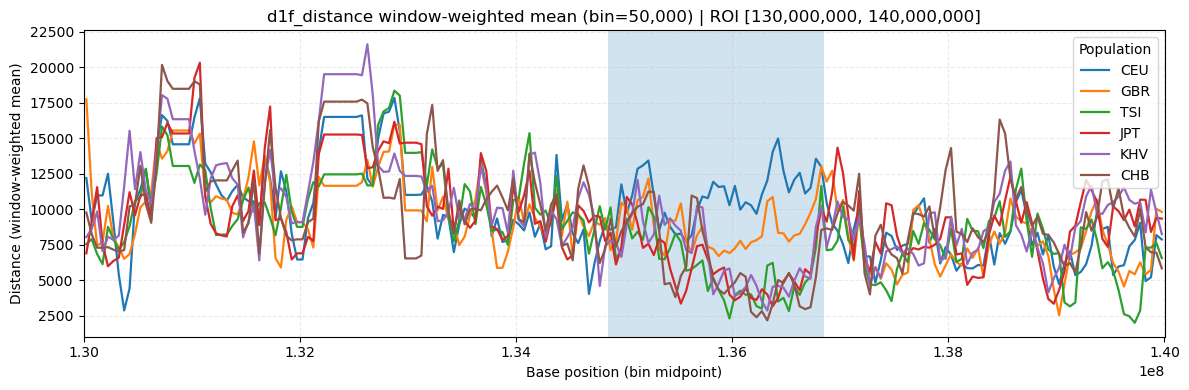

In [ ]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.3e8)
ROI_R = int(1.4e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_00

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the LCT highlight if it falls in ROI (it does)
pos = 135_851_076
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

In [5]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.0e8)
ROI_R = int(1.1e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the EDAR highlight if it falls in ROI (it does)
pos = 108_897_145
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'items'

## CEU vs JPT: Location vs mean D1F (post-burn-in, bin=100,000)

This section loads post-burn-in per-sample D1F CSVs from the new ARGweaver output layout, bins by 100,000 bp, and averages the binned curve over MCMC samples for each population (CEU, JPT).


CEU: 21 MCMC samples used
JPT: 21 MCMC samples used


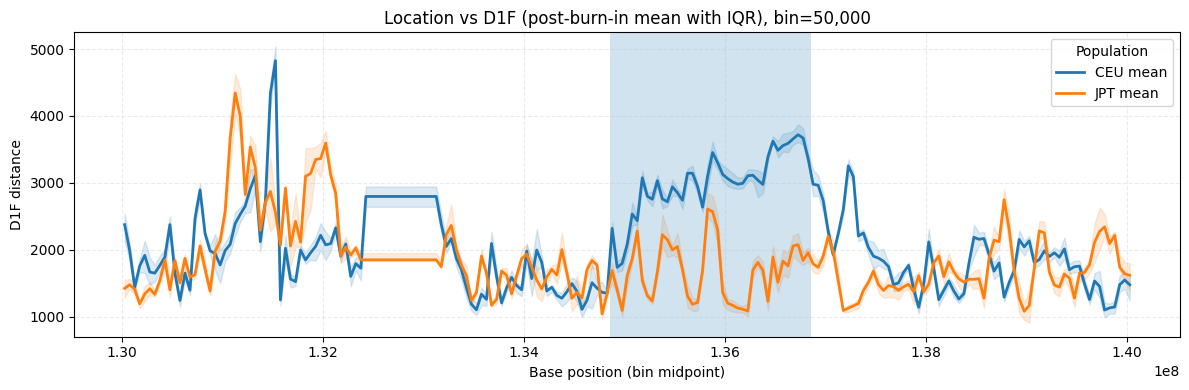

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

target_pops = ['CEU', 'JPT']
bin_size = 50_000

def load_pop_samples(pop: str):
    pattern = f'*_{pop}20/d1f_postburnin/*_d1f_per_tree_postburnin.csv'
    csv_paths = sorted(results_root.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No post-burn-in CSVs found for {pop} under {results_root}')

    sample_dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)

        dist_col = next((c for c in ['d1f_distance', 'distance', 'dif_distance'] if c in df.columns), None)
        if dist_col is None:
            raise KeyError(f'{p}: missing distance column')
        if not {'left', 'right'}.issubset(df.columns):
            raise KeyError(f'{p}: missing left/right columns')

        sample_match = re.search(r'sample(\d+)', p.name.lower())
        sample_id = int(sample_match.group(1)) if sample_match else None

        d = df[['left', 'right', dist_col]].copy()
        d.columns = ['left', 'right', 'd1f']
        d['sample'] = sample_id

        for c in ['left', 'right', 'd1f']:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        d = d.dropna(subset=['left', 'right', 'd1f'])
        d = d[d['right'] > d['left']]
        d = d.sort_values('left')

        if len(d):
            sample_dfs.append(d)

    if not sample_dfs:
        raise ValueError(f'All sample files for {pop} were empty after cleaning.')

    return sample_dfs

def binned_weighted_mean(df: pd.DataFrame, bin_left, bin_right):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df['d1f'].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out

# Load sample-level D1F data
pop_samples = {pop: load_pop_samples(pop) for pop in target_pops}

# Shared bin edges across both populations
x0 = min(df['left'].min() for dfs in pop_samples.values() for df in dfs)
x1 = max(df['right'].max() for dfs in pop_samples.values() for df in dfs)
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

# Average (mean) curve over MCMC samples + quantile bands per population
pop_stats = {}
for pop, dfs in pop_samples.items():
    per_sample_curves = np.vstack([binned_weighted_mean(d, bin_left, bin_right) for d in dfs])

    pop_stats[pop] = {
        'mean': np.nanmean(per_sample_curves, axis=0),
        'median': np.nanmedian(per_sample_curves, axis=0),
        'q1': np.nanquantile(per_sample_curves, 0.25, axis=0),
        'q3': np.nanquantile(per_sample_curves, 0.75, axis=0),
    }
    print(f'{pop}: {len(dfs)} MCMC samples used')

# Plot 2 lines (means) + quantile bands (Q1-Q3), styled like neutral-overlay section
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'CEU': 'tab:blue', 'JPT': 'tab:orange'}

for pop in target_pops:
    stats = pop_stats[pop]
    color = colors.get(pop, None)

    qmask = np.isfinite(stats['q1']) & np.isfinite(stats['q3'])
    ax.fill_between(bin_mid[qmask], stats['q1'][qmask], stats['q3'][qmask], color=color, alpha=0.15)

    mmask = np.isfinite(stats['mean'])
    ax.plot(bin_mid[mmask], stats['mean'][mmask], color=color, linewidth=2.0, label=f'{pop} mean')

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance')
ax.set_title(f'Location vs D1F (post-burn-in mean with IQR), bin={bin_size:,}')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population')
fig.tight_layout()
plt.show()


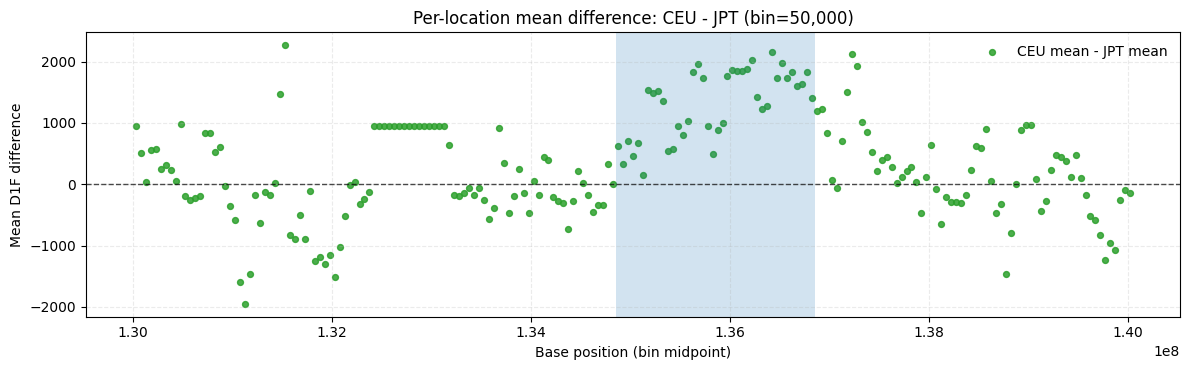

In [3]:
# CEU-JPT mean D1F difference per location (same bins as above)
diff_mean = pop_stats['CEU']['mean'] - pop_stats['JPT']['mean']
mask = np.isfinite(diff_mean)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.scatter(bin_mid[mask], diff_mean[mask], color='tab:green', s=18, alpha=0.85, label='CEU mean - JPT mean')
ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('Mean D1F difference')
ax.set_title(f'Per-location mean difference: CEU - JPT (bin={bin_size:,})')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



## Neutral SLiM Simulations For ARGweaver-Matched Populations (s=0)

This section runs **20 neutral SLiM simulations per population** (CEU, JPT) using the ARGweaver region settings and population-specific recombination maps.  
Each replicate then runs `recap.py` to recapitate, add neutral mutations, and downsample to 40 haploid genomes (20 diploids).



In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd

# Resolve repository root robustly
repo_root = Path.cwd()
if not (repo_root / 'Simulation').exists():
    for p in repo_root.parents:
        if (p / 'Simulation').exists():
            repo_root = p
            break

# Output root for neutral SLiM trees used as empirical baseline generation
neutral_root = repo_root / '1000Genomes' / 'raw_data' / 'data' / 'neutral_slim'
neutral_root.mkdir(parents=True, exist_ok=True)

# Pop-specific settings (match ARGweaver-scale settings; edit Ne if you used different values)
pop_configs = {
    'CEU': {
        'Ne': 14000,
        'mu': 1.25e-8,
    },
    'JPT': {
        'Ne': 14000,
        'mu': 1.25e-8,
    },
}

N_HAPLOID = 40                 # 20 diploid individuals
N_REPS = 20
FORWARD_GENERATIONS = 10000    # forward SLiM generations before recapitation
SEED_BASE = 9100000

slim_bin = 'slim'
recap_py = repo_root / 'Simulation' / 'Slim(primary)' / 'recap.py'
if not recap_py.exists():
    raise FileNotFoundError(f'Missing recap script: {recap_py}')



In [2]:
def load_recomb_map_for_slim(pop: str):
    """Read ARGweaver bedgraph recomb map and convert to SLiM vectors."""
    map_path = (
        repo_root
        / '1000Genomes' / 'raw_data' / 'data' / 'runs'
        / f'argweaver_chr2_130_140Mb_{pop}20'
        / 'intermediate'
        / 'recomb_map_chr2_130000000_140000000.bedgraph'
    )
    if not map_path.exists():
        raise FileNotFoundError(f'Missing recombination map for {pop}: {map_path}')

    df = pd.read_csv(map_path, sep='	', header=None, names=['chrom', 'start', 'end', 'rate'])
    if df.empty:
        raise ValueError(f'Empty recombination map for {pop}: {map_path}')

    region_start = int(df['start'].min())
    region_end = int(df['end'].max())
    seq_len = region_end - region_start

    # SLiM initializeRecombinationRate(rates, ends): len(ends) == len(rates)
    ends = (df['end'].astype(int) - region_start - 1).clip(lower=0).tolist()
    rates = df['rate'].astype(float).tolist()

    # Ensure final endpoint equals sequence length - 1
    if ends[-1] != seq_len - 1:
        ends[-1] = seq_len - 1

    return {
        'map_path': map_path,
        'region_start': region_start,
        'region_end': region_end,
        'seq_len': seq_len,
        'rates': rates,
        'ends': ends,
    }


def build_neutral_slim_script(seq_len: int, Ne: int, rates, ends, generations: int):
    rates_str = ', '.join(f'{r:.16g}' for r in rates)
    ends_str = ', '.join(str(e) for e in ends)

    template = """initialize() {{
    if (exists("slimgui")) {{
        defineConstant("simID", 1);
    }}
    initializeTreeSeq();
    initializeMutationRate(0);
    initializeMutationType("m1", 0.5, "f", 0.0);
    initializeGenomicElementType("g1", m1, 1.0);
    initializeGenomicElement(g1, 0, asInteger({seq_len} - 1));
    initializeRecombinationRate(c({rates_str}), c({ends_str}));
}}

1 early() {{
    sim.addSubpop("p1", asInteger({Ne}));
}}

{generations} late() {{
    sim.treeSeqOutput("trees/" + simID + \".trees");
    sim.simulationFinished();
}}
"""
    return template.format(
        seq_len=seq_len,
        rates_str=rates_str,
        ends_str=ends_str,
        Ne=Ne,
        generations=generations,
    )



In [3]:
def run_neutral_slim_for_population(pop: str, cfg: dict, n_reps: int = N_REPS):
    map_info = load_recomb_map_for_slim(pop)

    pop_dir = neutral_root / pop
    slimfiles_dir = pop_dir / 'slimfiles'
    trees_dir = pop_dir / 'trees'
    checkpoints_dir = pop_dir / 'checkpoints'
    for d in (slimfiles_dir, trees_dir, checkpoints_dir):
        d.mkdir(parents=True, exist_ok=True)

    slim_script = build_neutral_slim_script(
        seq_len=map_info['seq_len'],
        Ne=int(cfg['Ne']),
        rates=map_info['rates'],
        ends=map_info['ends'],
        generations=FORWARD_GENERATIONS,
    )

    slim_file = slimfiles_dir / f'neutral_{pop}_s0.slim'
    slim_file.write_text(slim_script)

    rows = []
    for rep in range(n_reps):
        sim_id = SEED_BASE + (100000 if pop == 'JPT' else 0) + rep

        raw_ts = trees_dir / f'{sim_id}.trees'
        recap_ts = trees_dir / f'r{sim_id}.trees'

        # Skip already-complete replicates
        if raw_ts.exists() and recap_ts.exists():
            rows.append({'population': pop, 'replicate': rep, 'sim_id': sim_id, 'raw_ts': str(raw_ts), 'recap_ts': str(recap_ts), 'status': 'existing'})
            continue

        slim_cmd = [
            slim_bin,
            '-s', str(sim_id),
            '-d', f'simID={sim_id}',
            str(slim_file),
        ]
        subprocess.run(slim_cmd, cwd=pop_dir, check=True)

        recap_cmd = [
            'python',
            str(recap_py),
            str(sim_id),
            str(N_HAPLOID),
            str(int(cfg['Ne'])),
            '0.0',                    # recap recombination already encoded in SLiM trees
            str(float(cfg['mu'])),
        ]
        subprocess.run(recap_cmd, cwd=pop_dir, check=True)

        rows.append({'population': pop, 'replicate': rep, 'sim_id': sim_id, 'raw_ts': str(raw_ts), 'recap_ts': str(recap_ts), 'status': 'generated'})

    manifest = pd.DataFrame(rows)
    manifest_path = pop_dir / f'neutral_manifest_{pop}.csv'
    manifest.to_csv(manifest_path, index=False)

    print(f'[{pop}] complete: {len(manifest)} replicates')
    print(f'[{pop}] manifest: {manifest_path}')
    print(f'[{pop}] recomb map: {map_info["map_path"]}')

    return manifest



In [ ]:
# Run 20 neutral SLiM replicates per population (CEU, JPT)
manifests = {}
for pop, cfg in pop_configs.items():
    manifests[pop] = run_neutral_slim_for_population(pop, cfg, n_reps=N_REPS)

summary = pd.concat(manifests.values(), ignore_index=True)
summary.groupby(['population', 'status']).size().rename('n').reset_index()



## Neutral TreeSequence Conversion Only (`.trees` -> `.tree` + `_breaks.csv`)
 
It converts neutral recapitated SLiM tree sequences directly into:
- cleaned Newick files (`*.tree`, one tree per line)
- breakpoint tables (`*_breaks.csv`)

Output layout matches the Rmd expectations:
- `raw_data/data/runs_neutral_slim_argweaver/argweaver_<RUN_TAG>/trees/*.tree`
- `raw_data/data/results/<RUN_TAG>/breakpoints/*_breaks.csv`



In [7]:
from pathlib import Path
import csv
import tskit

repo_root = Path.cwd()
if not (repo_root / 'Simulation').exists():
    for p in repo_root.parents:
        if (p / 'Simulation').exists():
            repo_root = p
            break

data_root = repo_root / '1000Genomes' / 'raw_data' / 'data'
neutral_root = data_root / 'neutral_slim'
neutral_runs_root = data_root / 'runs_neutral_slim_argweaver'
results_root = data_root / 'results'

neutral_runs_root.mkdir(parents=True, exist_ok=True)
results_root.mkdir(parents=True, exist_ok=True)

REGION_START = 130_000_000
REGION_END = 140_000_000


def discover_recap_trees(pop: str, max_n: int = 20):
    pop_dir = neutral_root / pop
    manifest_path = pop_dir / f'neutral_manifest_{pop}.csv'

    tpaths = []
    if manifest_path.exists():
        import pandas as pd
        m = pd.read_csv(manifest_path)
        if 'recap_ts' in m.columns:
            tpaths = [Path(x) for x in m['recap_ts'].tolist() if isinstance(x, str)]
            tpaths = [p for p in tpaths if p.exists()]

    if not tpaths:
        tpaths = sorted((pop_dir / 'trees').glob('r*.trees'))

    return sorted(tpaths)[:max_n]


def ts_to_newick_and_breaks(ts_path: Path, out_tree: Path, out_breaks_csv: Path, stem: str, region_start: int):
    ts = tskit.load(ts_path)

    sample_nodes = list(ts.samples())
    labels = {u: f'h{i}' for i, u in enumerate(sample_nodes)}

    out_tree.parent.mkdir(parents=True, exist_ok=True)
    out_breaks_csv.parent.mkdir(parents=True, exist_ok=True)

    with open(out_tree, 'w') as ftree, open(out_breaks_csv, 'w', newline='') as fcsv:
        w = csv.writer(fcsv)
        w.writerow(['file', 'tree_index', 'left', 'right', 'mid'])

        for tree in ts.trees():
            # Newick for current local tree
            nwk = tree.as_newick(root=tree.root, node_labels=labels)
            ftree.write(nwk + "\n")

            l = float(region_start + tree.interval.left)
            r = float(region_start + tree.interval.right)
            m = 0.5 * (l + r)
            w.writerow([stem, int(tree.index), l, r, m])


def convert_population(pop: str, max_n: int = 20):
    ts_files = discover_recap_trees(pop, max_n=max_n)
    if len(ts_files) == 0:
        print(f'[{pop}] no recap trees found')
        return []

    # Single neutral run directory per population (Rmd expects argweaver_* style naming)
    run_tag = f'chr2_130_140Mb_{pop}20_neutral'
    run_dir = neutral_runs_root / f'argweaver_{run_tag}'
    tree_dir = run_dir / 'trees'
    breaks_dir = results_root / run_tag / 'breakpoints'

    tree_dir.mkdir(parents=True, exist_ok=True)
    breaks_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for i, ts_path in enumerate(ts_files, start=0):
        # Set sample IDs > 90 so existing Rmd post-burn-in filter keeps them.
        sample_id = 100 + 10 * i
        stem = f'{pop.lower()}_sample{sample_id}'

        out_tree = tree_dir / f'{stem}.tree'
        out_breaks = breaks_dir / f'{stem}_breaks.csv'

        ts_to_newick_and_breaks(
            ts_path=ts_path,
            out_tree=out_tree,
            out_breaks_csv=out_breaks,
            stem=stem,
            region_start=REGION_START,
        )

        rows.append({
            'population': pop,
            'ts_path': str(ts_path),
            'run_tag': run_tag,
            'tree_file': str(out_tree),
            'breaks_file': str(out_breaks),
            'sample_id': sample_id,
        })

    return rows


all_rows = []
for pop in ['CEU', 'JPT']:
    all_rows.extend(convert_population(pop, max_n=20))

if all_rows:
    import pandas as pd
    manifest = pd.DataFrame(all_rows)
    manifest_path = neutral_runs_root / 'neutral_trees_direct_conversion_manifest.csv'
    manifest.to_csv(manifest_path, index=False)
    print(f'Wrote conversion manifest: {manifest_path}')
    display(manifest.groupby('population').size().rename('n_files').reset_index())
else:
    print('No files converted.')



Wrote conversion manifest: /Users/yagishinnosuke/Documents/2025-2026 Stanford/Palacios Lab/Selective-Sweep-Simulation/1000Genomes/raw_data/data/runs_neutral_slim_argweaver/neutral_trees_direct_conversion_manifest.csv


,population,n_files
0,CEU,20
1,JPT,20


## CEU vs JPT: Location vs mean D1F to empirical neutral mean (post-burn-in)

This section reproduces the distance-vs-location plot using the empirical-neutral-reference outputs from `chr2_20samples_d1f_argweaver.Rmd` (`*_postburnin_empirical_neutral.csv`).



CEU: 21 empirical-reference samples used
JPT: 21 empirical-reference samples used


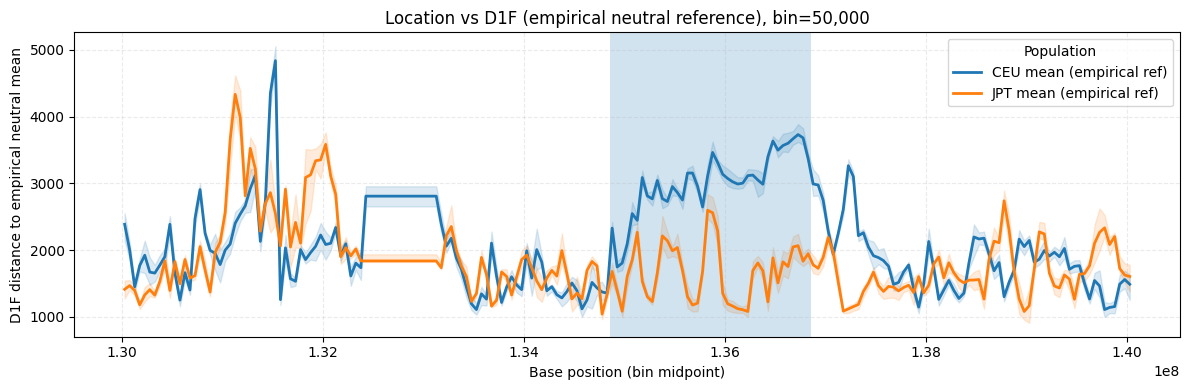

In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

target_pops_emp = ['CEU', 'JPT']
bin_size_emp = 50_000


def load_pop_samples_empirical(pop: str):
    pattern = f'*_{pop}20/d1f_postburnin_empirical_neutral/*_d1f_per_tree_postburnin_empirical_neutral.csv'
    csv_paths = sorted(results_root.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No empirical-neutral CSVs found for {pop} under {results_root}')

    sample_dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)

        dist_col = next((c for c in ['d1f_distance', 'distance', 'dif_distance'] if c in df.columns), None)
        if dist_col is None:
            raise KeyError(f'{p}: missing distance column')
        if not {'left', 'right'}.issubset(df.columns):
            raise KeyError(f'{p}: missing left/right columns')

        sample_match = re.search(r'sample(\d+)', p.name.lower())
        sample_id = int(sample_match.group(1)) if sample_match else None

        d = df[['left', 'right', dist_col]].copy()
        d.columns = ['left', 'right', 'd1f_emp']
        d['sample'] = sample_id

        for c in ['left', 'right', 'd1f_emp']:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        d = d.dropna(subset=['left', 'right', 'd1f_emp'])
        d = d[d['right'] > d['left']]
        d = d.sort_values('left')

        if len(d):
            sample_dfs.append(d)

    if not sample_dfs:
        raise ValueError(f'All empirical-neutral files for {pop} were empty after cleaning.')

    return sample_dfs


def binned_weighted_mean_emp(df: pd.DataFrame, bin_left, bin_right):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df['d1f_emp'].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out


# Load sample-level empirical-reference D1F data
pop_samples_emp = {pop: load_pop_samples_empirical(pop) for pop in target_pops_emp}

# Shared bin edges
x0 = min(df['left'].min() for dfs in pop_samples_emp.values() for df in dfs)
x1 = max(df['right'].max() for dfs in pop_samples_emp.values() for df in dfs)
x0 = (int(x0) // bin_size_emp) * bin_size_emp
x1 = int(np.ceil(x1 / bin_size_emp) * bin_size_emp)

bin_edges_emp = np.arange(x0, x1 + bin_size_emp, bin_size_emp, dtype=np.int64)
bin_left_emp = bin_edges_emp[:-1]
bin_right_emp = bin_edges_emp[1:]
bin_mid_emp = (bin_left_emp + bin_right_emp) / 2.0

# Aggregate over samples
pop_stats_emp = {}
for pop, dfs in pop_samples_emp.items():
    per_sample_curves = np.vstack([binned_weighted_mean_emp(d, bin_left_emp, bin_right_emp) for d in dfs])

    pop_stats_emp[pop] = {
        'mean': np.nanmean(per_sample_curves, axis=0),
        'median': np.nanmedian(per_sample_curves, axis=0),
        'q1': np.nanquantile(per_sample_curves, 0.25, axis=0),
        'q3': np.nanquantile(per_sample_curves, 0.75, axis=0),
    }
    print(f'{pop}: {len(dfs)} empirical-reference samples used')

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'CEU': 'tab:blue', 'JPT': 'tab:orange'}

for pop in target_pops_emp:
    stats = pop_stats_emp[pop]
    color = colors.get(pop, None)

    qmask = np.isfinite(stats['q1']) & np.isfinite(stats['q3'])
    ax.fill_between(bin_mid_emp[qmask], stats['q1'][qmask], stats['q3'][qmask], color=color, alpha=0.15)

    mmask = np.isfinite(stats['mean'])
    ax.plot(bin_mid_emp[mmask], stats['mean'][mmask], color=color, linewidth=2.0, label=f'{pop} mean (empirical ref)')

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance to empirical neutral mean')
ax.set_title(f'Location vs D1F (empirical neutral reference), bin={bin_size_emp:,}')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population')
fig.tight_layout()
plt.show()



## Verification: Theoretical vs Empirical Reference D1F

This diagnostic section confirms whether the empirical-reference pipeline is being used by directly comparing post-burn-in per-tree D1F outputs from:
- theoretical Kingman reference (`d1f_postburnin`)
- empirical neutral reference (`d1f_postburnin_empirical_neutral`)



,population,sample,n_rows,mean_theo,mean_emp,mean_diff_emp_minus_theo,abs_diff_mean,corr
0,CEU,100,13121,1857.923148,1867.356187,9.433039,9.564467,0.999990
1,CEU,110,13106,1850.773690,1860.276380,9.502690,9.632653,0.999990
2,CEU,120,12952,1867.434199,1876.942172,9.507973,9.629121,0.999990
3,CEU,130,12938,1868.242651,1877.807383,9.564732,9.651458,0.999991
4,CEU,140,13079,1861.906519,1871.682441,9.775922,9.849512,0.999992


,population,sample,n_rows,mean_theo,mean_emp,mean_diff_emp_minus_theo,abs_diff_mean,corr
0,JPT,100,15196,1737.297332,1727.604010,-9.693322,9.791298,0.999985
1,JPT,110,15130,1748.354832,1738.746969,-9.607863,9.727336,0.999985
2,JPT,120,14932,1734.573917,1724.981722,-9.592195,9.733924,0.999983
3,JPT,130,14983,1749.346406,1739.758061,-9.588344,9.724005,0.999984
4,JPT,140,14949,1728.169423,1718.654898,-9.514525,9.658993,0.999982


CEU mean abs diff: 9.842580550468131
JPT mean abs diff: 9.585830562612378
CEU mean corr: 0.9999907656483726
JPT mean corr: 0.9999831226582064


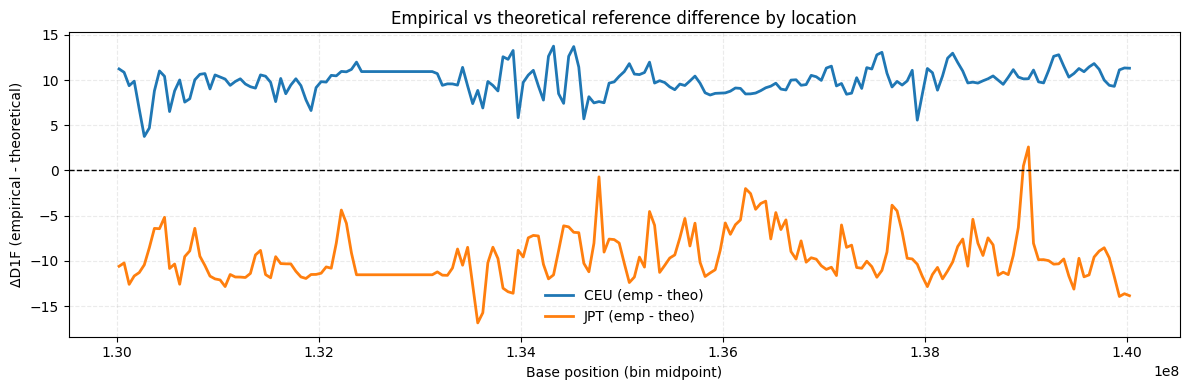

In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

def sample_id_from_name(name: str):
    m = re.search(r'sample(\d+)', name.lower())
    return int(m.group(1)) if m else None

def compare_pop(pop: str):
    theo_dir = results_root / f'chr2_130_140Mb_{pop}20' / 'd1f_postburnin'
    emp_dir = results_root / f'chr2_130_140Mb_{pop}20' / 'd1f_postburnin_empirical_neutral'

    theo_files = sorted(theo_dir.glob(f'{pop.lower()}_sample*_d1f_per_tree_postburnin.csv'))
    emp_files = sorted(emp_dir.glob(f'{pop.lower()}_sample*_d1f_per_tree_postburnin_empirical_neutral.csv'))

    theo_map = {sample_id_from_name(p.name): p for p in theo_files}
    emp_map = {sample_id_from_name(p.name): p for p in emp_files}
    common = sorted(set(theo_map) & set(emp_map))

    if not common:
        raise ValueError(f'No matching sample IDs between theoretical and empirical for {pop}')

    rows = []
    merged_list = []
    for sid in common:
        t = pd.read_csv(theo_map[sid])
        e = pd.read_csv(emp_map[sid])

        # Align on genomic window identity
        key_cols = ['file', 'tree_index', 'left', 'right', 'mid']
        use_cols = [c for c in key_cols if c in t.columns and c in e.columns]
        m = t.merge(e, on=use_cols, suffixes=('_theo', '_emp'))

        if 'd1f_distance_theo' not in m.columns or 'd1f_distance_emp' not in m.columns:
            raise KeyError(f'{pop} sample {sid}: missing d1f_distance columns after merge')

        d = m['d1f_distance_emp'] - m['d1f_distance_theo']
        rows.append({
            'population': pop,
            'sample': sid,
            'n_rows': len(m),
            'mean_theo': float(m['d1f_distance_theo'].mean()),
            'mean_emp': float(m['d1f_distance_emp'].mean()),
            'mean_diff_emp_minus_theo': float(d.mean()),
            'abs_diff_mean': float(d.abs().mean()),
            'corr': float(m['d1f_distance_theo'].corr(m['d1f_distance_emp'])),
        })

        merged_list.append(m)

    summary = pd.DataFrame(rows).sort_values('sample')
    merged_all = pd.concat(merged_list, ignore_index=True)
    return summary, merged_all

summary_ceu, merged_ceu = compare_pop('CEU')
summary_jpt, merged_jpt = compare_pop('JPT')

display(summary_ceu.head())
display(summary_jpt.head())

print('CEU mean abs diff:', summary_ceu['abs_diff_mean'].mean())
print('JPT mean abs diff:', summary_jpt['abs_diff_mean'].mean())
print('CEU mean corr:', summary_ceu['corr'].mean())
print('JPT mean corr:', summary_jpt['corr'].mean())

# Difference-vs-location plot (empirical - theoretical), binned
bin_size = 50_000

def binned_delta(df):
    x0 = (int(df['left'].min()) // bin_size) * bin_size
    x1 = int(np.ceil(df['right'].max() / bin_size) * bin_size)
    edges = np.arange(x0, x1 + bin_size, bin_size)
    L = edges[:-1]
    R = edges[1:]
    M = (L + R) / 2.0
    out = np.full(len(L), np.nan)

    seg_l = df['left'].to_numpy(float)
    seg_r = df['right'].to_numpy(float)
    seg_d = (df['d1f_distance_emp'] - df['d1f_distance_theo']).to_numpy(float)

    for i, (a, b) in enumerate(zip(L, R)):
        ov = np.minimum(seg_r, b) - np.maximum(seg_l, a)
        mask = ov > 0
        if np.any(mask):
            w = ov[mask]
            out[i] = np.sum(w * seg_d[mask]) / np.sum(w)
    return M, out

mid_ceu, d_ceu = binned_delta(merged_ceu)
mid_jpt, d_jpt = binned_delta(merged_jpt)

fig, ax = plt.subplots(figsize=(12, 4))
mask = np.isfinite(d_ceu)
ax.plot(mid_ceu[mask], d_ceu[mask], color='tab:blue', linewidth=2, label='CEU (emp - theo)')
mask = np.isfinite(d_jpt)
ax.plot(mid_jpt[mask], d_jpt[mask], color='tab:orange', linewidth=2, label='JPT (emp - theo)')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('ΔD1F (empirical - theoretical)')
ax.set_title('Empirical vs theoretical reference difference by location')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

